## **Customer Churn Prediction**


This project will include:

1.  EDA (Exploratory Data Analysis): Explore the behavior of churned users and make recommendations.
2.  Supervised Learning: Build a Machine Learning model to predict user churn.
3.  Unsupervised Learning: Segment churned users into different groups based on their behavior.

## **A. EDA**

### **Bước 1: Data Cleaning (Làm sạch dữ liệu)**

1.1 Kiểm tra tổng quan & Xử lý giá trị thiếu

In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_excel('/content/churn_prediction.xlsx')

# Kiểm tra thông tin tổng quát và giá trị thiếu
print(df.head())
print(df.info())
print((df.describe(include='all')))

   CustomerID  Churn  Tenure PreferredLoginDevice  CityTier  WarehouseToHome  \
0       52869      0    20.0         Mobile Phone         3              7.0   
1       52942      0    13.0             Computer         1              9.0   
2       52972      0    16.0         Mobile Phone         3              7.0   
3       53125      0     5.0         Mobile Phone         1             16.0   
4       53367      0     9.0         Mobile Phone         1             28.0   

  PreferredPaymentMode  Gender  HourSpendOnApp  NumberOfDeviceRegistered  \
0             E wallet  Female             4.0                         4   
1     Cash on Delivery  Female             4.0                         4   
2           Debit Card    Male             3.0                         4   
3           Debit Card    Male             3.0                         4   
4           Debit Card  Female             3.0                         4   

     PreferedOrderCat  SatisfactionScore MaritalStatus  Number

In [32]:
# Missing  Data
df.isnull().sum()

,0
CustomerID,0
Churn,0
Tenure,264
PreferredLoginDevice,0
CityTier,0
WarehouseToHome,251
PreferredPaymentMode,0
Gender,0
HourSpendOnApp,255
NumberOfDeviceRegistered,0


In [33]:
# Duplicate Data
df.duplicated().sum()

np.int64(0)

In [34]:
# Xử lý giá trị thiếu:
# Median cho cột số
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Mode cho cột cat
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [35]:
# Re Check
display(df.isnull().sum())

,0
CustomerID,0
Churn,0
Tenure,0
PreferredLoginDevice,0
CityTier,0
WarehouseToHome,0
PreferredPaymentMode,0
Gender,0
HourSpendOnApp,0
NumberOfDeviceRegistered,0


In [36]:
# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove 'CustomerID' and 'Churn'vì không cần lắm
if 'CustomerID' in numerical_cols:
    numerical_cols.remove('CustomerID')
if 'Churn' in numerical_cols:
    numerical_cols.remove('Churn')

1.2 Xử lý trùng lặp & Loại bỏ cột thừa

In [37]:
# Loại bỏ dòng trùng lặp hoàn toàn
df.drop_duplicates(inplace=True)

### **Bước 2: Univariate Analysis (Phân tích đơn biến)**

/tmp/ipykernel_1190/1085659002.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


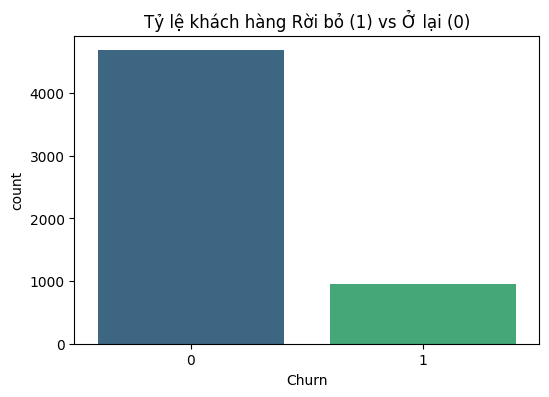

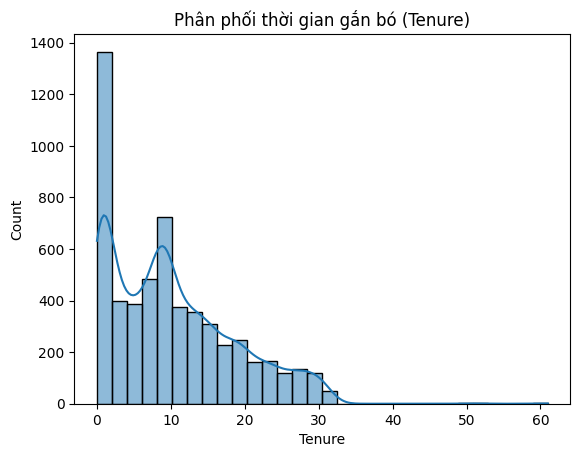

In [38]:
# Kiểm tra tỷ lệ Churn
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Tỷ lệ khách hàng Rời bỏ (1) vs Ở lại (0)')
plt.show()

# Kiểm tra phân phối Tenure
sns.histplot(df['Tenure'], bins=30, kde=True)
plt.title('Phân phối thời gian gắn bó (Tenure)')
plt.show()

*   -> Dữ liệu Mất cân bằng churn(0) gấp 5 lần churn(1)
*   -> Khách hay bỏ ngay đoạn đầu thử nghiệm

### **Bước 3: Bivariate Analysis (Phân tích hành vi)**

3.1 Hành vi dựa trên Khiếu nại (Complain)

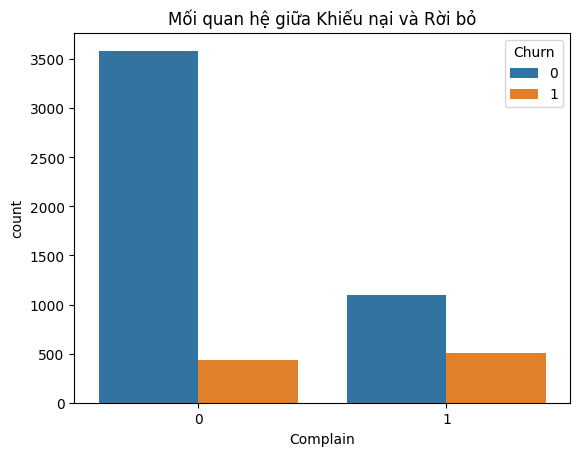

In [39]:
sns.countplot(x='Complain', hue='Churn', data=df)
plt.title('Mối quan hệ giữa Khiếu nại và Rời bỏ')
plt.show()

-> khách complain rời đi nhiều hơn là không

3.2 Hành vi dựa trên thời gian gắn bó (Tenure) & Khoảng cách (WarehouseToHome)

/tmp/ipykernel_1190/1182189801.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Churn']==1]['Tenure'], label='Rời bỏ', shade=True)
/tmp/ipykernel_1190/1182189801.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Churn']==0]['Tenure'], label='Ở lại', shade=True)


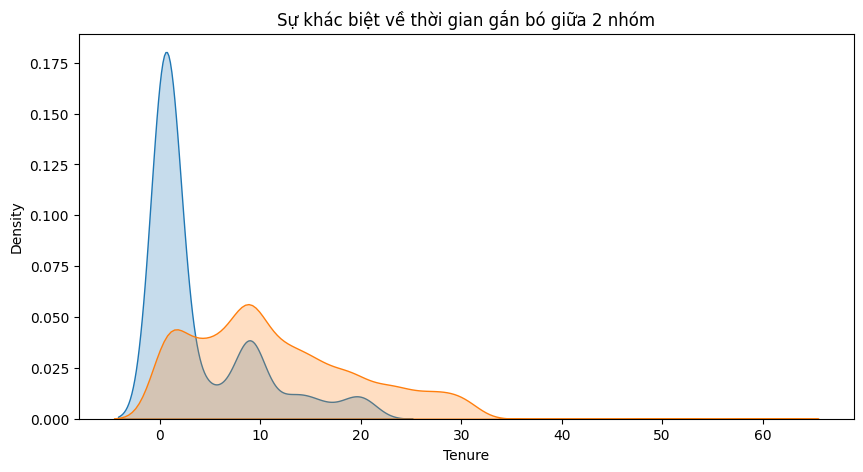

In [40]:
plt.figure(figsize=(10,5))
sns.kdeplot(df[df['Churn']==1]['Tenure'], label='Rời bỏ', shade=True)
sns.kdeplot(df[df['Churn']==0]['Tenure'], label='Ở lại', shade=True)
plt.title('Sự khác biệt về thời gian gắn bó giữa 2 nhóm')
plt.show()

3.3 Hành vi của khách rời bỏ theo các nhóm thông tin (City Tier, loại hàng hay mua, thiết bị đăng nhập, hôn nhân, hình thức thanh toán, giới tính)

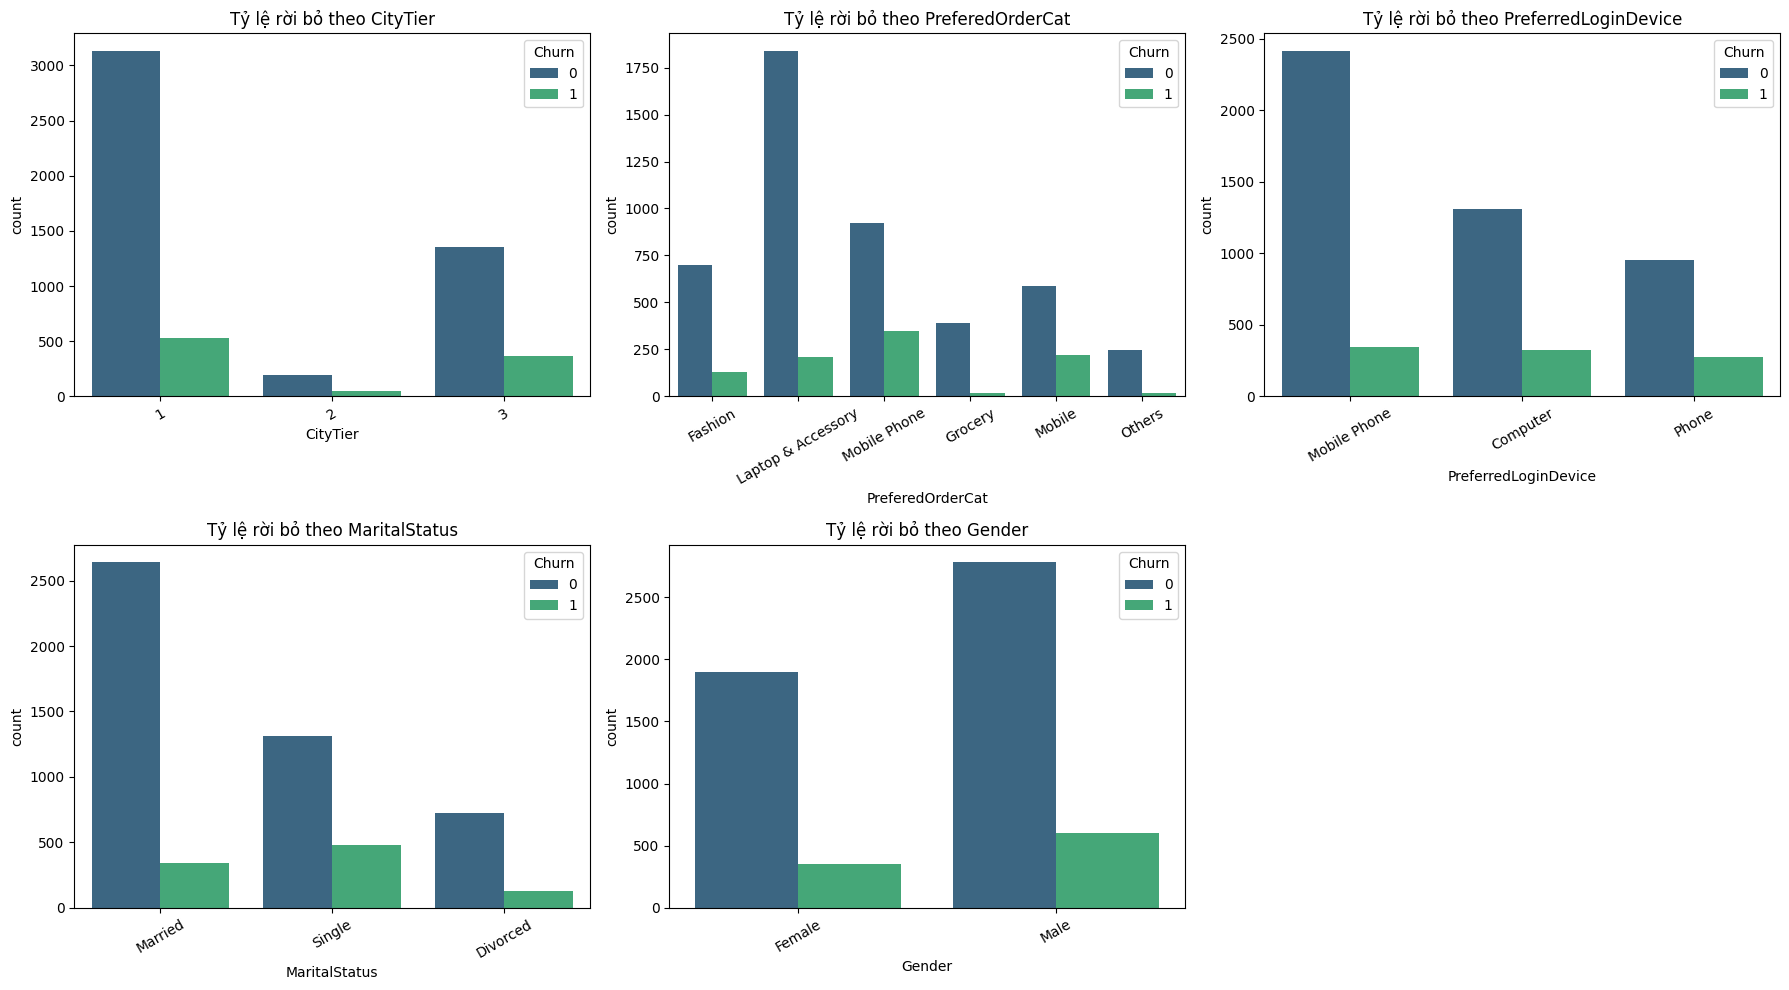

--- Tỷ lệ rời bỏ (%) theo CityTier ---
CityTier
1    14.51
2    19.83
3    21.37
Name: Churn, dtype: float64

--- Tỷ lệ rời bỏ (%) theo PreferedOrderCat ---
PreferedOrderCat
Fashion               15.50
Grocery                4.88
Laptop & Accessory    10.24
Mobile                27.19
Mobile Phone          27.54
Others                 7.58
Name: Churn, dtype: float64

--- Tỷ lệ rời bỏ (%) theo PreferredLoginDevice ---
PreferredLoginDevice
Computer        19.83
Mobile Phone    12.59
Phone           22.42
Name: Churn, dtype: float64

--- Tỷ lệ rời bỏ (%) theo MaritalStatus ---
MaritalStatus
Divorced    14.62
Married     11.52
Single      26.73
Name: Churn, dtype: float64

--- Tỷ lệ rời bỏ (%) theo Gender ---
Gender
Female    15.49
Male      17.73
Name: Churn, dtype: float64



In [41]:
# So sánh tỷ lệ rời bỏ (Churn) theo từng nhóm khách hàng
# Mục đích: xem nhóm khách nào có xu hướng rời bỏ nhiều hơn

cat_features_to_check = [
    'CityTier', 'PreferedOrderCat', 'PreferredLoginDevice',
    'MaritalStatus', 'PreferPayment', 'Gender'
]

# Chỉ giữ lại các cột thực sự có trong dữ liệu
cat_features_to_check = [c for c in cat_features_to_check if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features_to_check):
    sns.countplot(x=col, hue='Churn', data=df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Tỷ lệ rời bỏ theo {col}')
    axes[i].tick_params(axis='x', rotation=30)

# Ẩn các ô biểu đồ trống không dùng
for j in range(len(cat_features_to_check), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# In ra tỷ lệ rời bỏ (%) theo từng nhóm
# Giúp phát hiện nhóm nào có tỷ lệ rời bỏ cao bất thường
for col in cat_features_to_check:
    print('--- Tỷ lệ rời bỏ (%) theo ' + col + ' ---')
    churn_rate = df.groupby(col)['Churn'].mean() * 100
    print(churn_rate.round(2))
    print()

**Nhận xét (Bước 3.3):**

- **CityTier**: Tỷ lệ rời bỏ ở Tier 1 và Tier 3 cao hơn rõ rệt so với Tier 2. Có thể do đặc điểm dịch vụ/giao hàng khác nhau giữa các khu vực.
- **PreferedOrderCat**: Nhóm khách thường mua **Mobile Phone** và **Laptop & Accessory** có tỷ lệ rời bỏ đáng kể, đây là các nhóm hàng giá trị cao - có thể nhạy cảm hơn về trải nghiệm mua hàng và giao hàng.
- **PreferredLoginDevice**: Không có sự khác biệt quá lớn giữa các thiết bị, nhưng nhóm dùng **Mobile Phone** chiếm số lượng churn cao nhất (do cũng là nhóm dùng nhiều nhất).
- **MaritalStatus**: Khách **Single** có tỷ lệ rời bỏ cao hơn so với Married và Divorced - có thể do ít gắn bó lâu dài với thương hiệu.
- **Gender**: Khách **Male** có số lượng rời bỏ cao hơn Female cả về số lượng tuyệt đối và tỷ lệ.

-> Đây là cơ sở để công ty cân nhắc các chương trình giữ chân riêng theo từng nhóm khách hàng (ví dụ: ưu đãi giao hàng cho khách ở Tier 1/3, ưu đãi riêng cho nhóm mua điện thoại/laptop, chương trình loyalty cho khách Single).

### **Bước 4: Detect and Treat Outliers**

In [42]:
cols_to_fix = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'OrderAmountHikeFromlastYear',
               'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

for col in cols_to_fix:
    data_col = df[col]
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Lọc Outlier
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    print(f"Đã làm sạch Outlier cho cột: {col}")

Đã làm sạch Outlier cho cột: Tenure
Đã làm sạch Outlier cho cột: WarehouseToHome
Đã làm sạch Outlier cho cột: HourSpendOnApp
Đã làm sạch Outlier cho cột: OrderAmountHikeFromlastYear
Đã làm sạch Outlier cho cột: CouponUsed
Đã làm sạch Outlier cho cột: OrderCount
Đã làm sạch Outlier cho cột: DaySinceLastOrder
Đã làm sạch Outlier cho cột: CashbackAmount


### **Bước 5: Feature Importance với Random Forest**

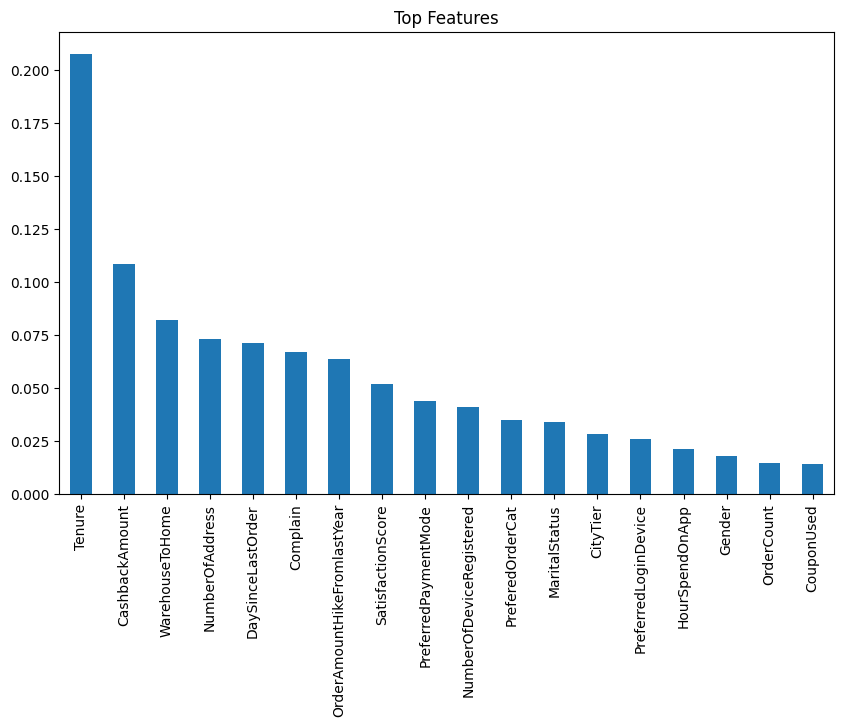

In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Encoding các biến chữ thành số
le = LabelEncoder()
df_encoded = df.copy()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df[col])

# Train Base Model
X = df_encoded.drop(['Churn', 'CustomerID'], axis=1)
y = df_encoded['Churn']
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

# Trực quan hóa Feature Importance
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
importances.plot(kind='bar')
plt.title('Top Features')
plt.show()

## **B. Supervised Learning**

### **Bước 1: Chia dữ liệu (Train-Test Split)**

In [44]:
from sklearn.model_selection import train_test_split

# Tách Features (X) và Target (y)
# Lưu ý: Loại bỏ CustomerID vì nó không có ý nghĩa dự báo
X = df_encoded.drop(['Churn', 'CustomerID'], axis=1)
y = df_encoded['Churn']

# Chia dữ liệu
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}")

Kích thước tập Train: (3066, 18)
Kích thước tập Test: (767, 18)


### **Bước 2: Huấn luyện mô hình Random Forest**

In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Khởi tạo mô hình
# class_weight='balanced' sẽ giúp mô hình "ưu tiên" bắt đúng nhóm Churn (nhóm thiểu số)
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight='balanced',
    random_state=42
)

# Huấn luyện
rf_model.fit(X_train, y_train)

# Dự đoán
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1] # Lấy xác suất để tính điểm AUC

### **Bước 3: Đánh giá kết quả**

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       617
           1       0.94      0.87      0.90       150

    accuracy                           0.96       767
   macro avg       0.95      0.93      0.94       767
weighted avg       0.96      0.96      0.96       767

ROC-AUC Score: 0.9906


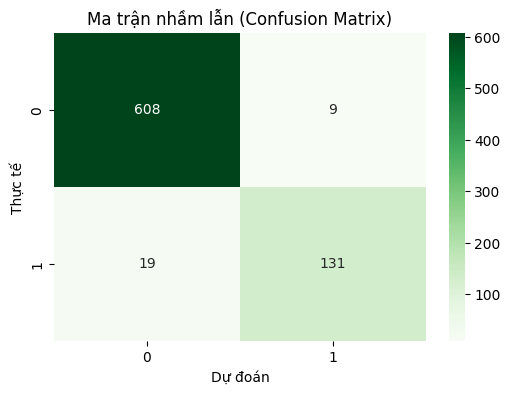

In [46]:
# 1. In báo cáo chi tiết
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 2. Tính AUC-ROC
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# 3. Vẽ Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Ma trận nhầm lẫn (Confusion Matrix)')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.show()

### **Bước 4: Hyperparameter Tuning**

In [47]:
#Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'bootstrap': [True, False]
}

grid_search = GridSearchCV(rf_model, param_grid, cv=5, scoring='balanced_accuracy')
grid_search.fit(X_train, y_train)

print("Best Parameters: ", grid_search.best_params_)


Best Parameters:  {'bootstrap': False, 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


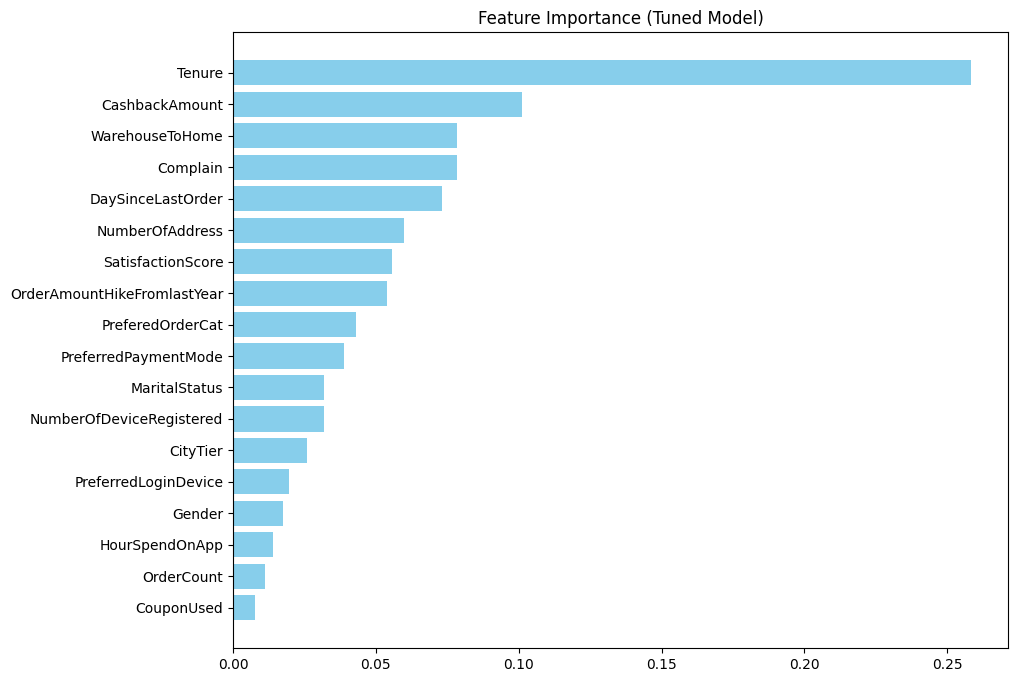

In [48]:
#Feature Importance (Tuned Model)
best_clf = grid_search.best_estimator_
feats = {}
for feature, importance in zip(X.columns, best_clf.feature_importances_):
    feats[feature] = importance

importances = pd.DataFrame.from_dict(feats, orient='index').rename(columns={0: 'Gini-importance'})
importances = importances.sort_values(by='Gini-importance', ascending=True).reset_index()

plt.figure(figsize=(10, 8))
plt.barh(importances['index'], importances['Gini-importance'], color='skyblue')
plt.title('Feature Importance (Tuned Model)')
plt.show()

## **C. Unsupervised Learning**

### **Bước 1: Chuẩn bị dữ liệu và Tìm số cụm tối ưu (Elbow Method)**

**Note:**

Nếu tất cả các cột để phân cụm, biểu đồ WCSS giảm đều, không xuất hiện điểm “khúc gấp” rõ ràng → khó chọn số cụm K bằng Elbow Method.

Cách **khắc phục** là thử nhiều nhóm đặc điểm (feature set) khác nhau thay vì gom hết mọi cột.
Với mỗi nhóm đặc điểm, chạy cả Elbow Method và tính Silhouette Score để chọn số cụm K hợp lý.

================= Set1_Behavioral_Value =================
Các cột sử dụng: ['Tenure', 'CashbackAmount', 'SatisfactionScore', 'Complain', 'OrderCount', 'DaySinceLastOrder', 'HourSpendOnApp']
K | Silhouette Score | WCSS
2 | 0.2010            | 4142.62
3 | 0.1867            | 3682.33
4 | 0.1835            | 3330.36
5 | 0.1879            | 3030.62
6 | 0.2042            | 2761.86
7 | 0.1979            | 2611.80
8 | 0.2012            | 2465.50


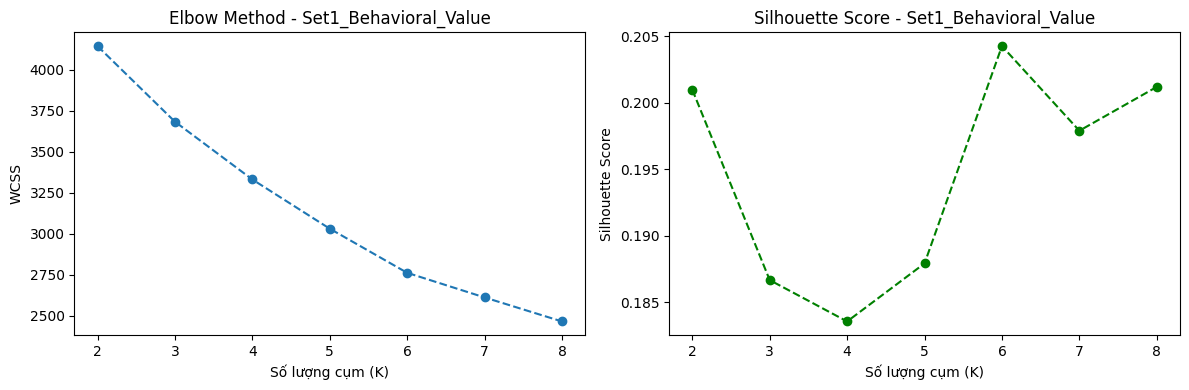


================= Set2_Logistics_Service =================
Các cột sử dụng: ['WarehouseToHome', 'Complain', 'SatisfactionScore', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'DaySinceLastOrder']
K | Silhouette Score | WCSS
2 | 0.1850            | 3722.60
3 | 0.1812            | 3308.58
4 | 0.1893            | 2984.99
5 | 0.1924            | 2686.95
6 | 0.1828            | 2476.04
7 | 0.1908            | 2312.05
8 | 0.1901            | 2167.79


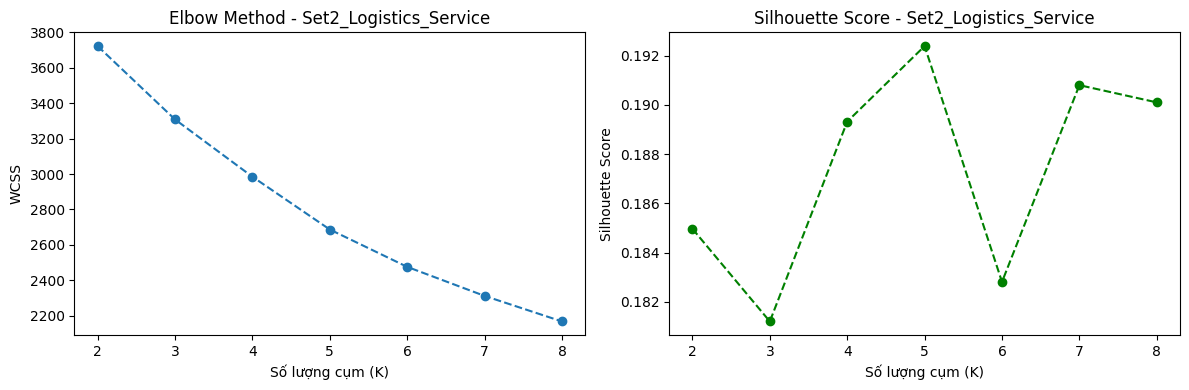


================= Set3_All_Numeric_Baseline =================
Các cột sử dụng: ['Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']
K | Silhouette Score | WCSS
2 | 0.1171            | 11810.98
3 | 0.1121            | 10836.01
4 | 0.0940            | 10431.41
5 | 0.0939            | 10121.86
6 | 0.0784            | 9853.62
7 | 0.0792            | 9574.87
8 | 0.0769            | 9354.24


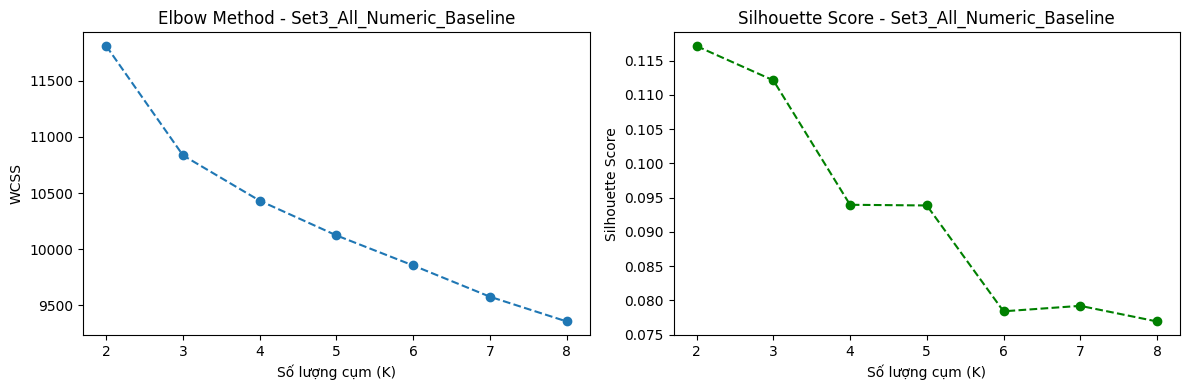


================= Set4_Behavioral_NoSatisfaction =================
Các cột sử dụng: ['Tenure', 'CashbackAmount', 'Complain', 'OrderCount', 'DaySinceLastOrder', 'HourSpendOnApp']
K | Silhouette Score | WCSS
2 | 0.2374            | 3394.65
3 | 0.2313            | 2944.18
4 | 0.2432            | 2589.70
5 | 0.2532            | 2293.36
6 | 0.2674            | 2042.74
7 | 0.2704            | 1863.15
8 | 0.2808            | 1742.87


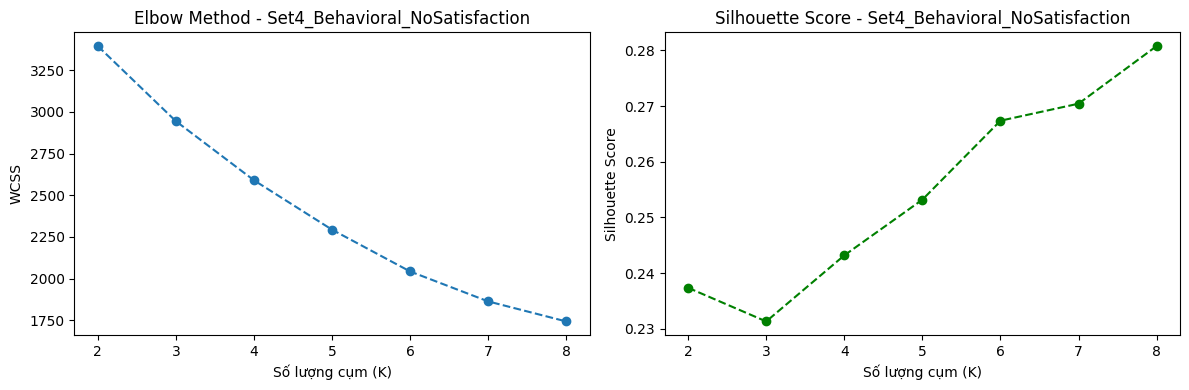

In [49]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# 1. Chỉ lấy những khách hàng đã rời bỏ (Churn = 1)
churn_df = df_encoded[df_encoded['Churn'] == 1].copy()

# 2. Các nhóm đặc điểm (feature set) để thử phân cụm
#    - Set1: Hành vi & Giá trị (thời gian gắn bó, chi tiêu, hài lòng, sử dụng app...)
#    - Set2: Trải nghiệm giao hàng & dịch vụ (khoảng cách kho, khiếu nại...)
#    - Set3: Toàn bộ các cột số (cách làm cũ, để so sánh)
#    - Set4: Giống Set1 nhưng bỏ SatisfactionScore
feature_sets = {
    'Set1_Behavioral_Value': [
        'Tenure', 'CashbackAmount', 'SatisfactionScore',
        'Complain', 'OrderCount', 'DaySinceLastOrder', 'HourSpendOnApp'
    ],
    'Set2_Logistics_Service': [
        'WarehouseToHome', 'Complain', 'SatisfactionScore',
        'OrderAmountHikeFromlastYear', 'CouponUsed', 'DaySinceLastOrder'
    ],
    'Set3_All_Numeric_Baseline': [
        col for col in churn_df.drop(['Churn', 'CustomerID'], axis=1).columns
    ],
    'Set4_Behavioral_NoSatisfaction': [
        'Tenure', 'CashbackAmount', 'Complain',
        'OrderCount', 'DaySinceLastOrder', 'HourSpendOnApp'
    ],
}

# Chỉ giữ các cột thực sự có trong dữ liệu
for name in feature_sets:
    feature_sets[name] = [c for c in feature_sets[name] if c in churn_df.columns]

K_RANGE = range(2, 9)  # K=1 không có ý nghĩa với Silhouette Score

results = {}  # lưu lại wcss, silhouette và dữ liệu đã chuẩn hóa cho từng feature set

for set_name, cols in feature_sets.items():
    print('================= ' + set_name + ' =================')
    print('Các cột sử dụng:', cols)

    X_subset = churn_df[cols]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_subset)

    wcss = []
    sil_scores = []

    for k in K_RANGE:
        kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_scaled)
        wcss.append(kmeans.inertia_)
        sil_scores.append(silhouette_score(X_scaled, labels))

    results[set_name] = {
        'K_RANGE': list(K_RANGE),
        'wcss': wcss,
        'silhouette': sil_scores,
        'scaled_features': X_scaled,
        'columns': cols,
    }

    # In bảng Silhouette / WCSS
    print('K | Silhouette Score | WCSS')
    for k, s, w in zip(K_RANGE, sil_scores, wcss):
        print(f'{k} | {s:.4f}            | {w:.2f}')

    # Vẽ 2 biểu đồ: Elbow và Silhouette
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(list(K_RANGE), wcss, marker='o', linestyle='--')
    axes[0].set_title('Elbow Method - ' + set_name)
    axes[0].set_xlabel('Số lượng cụm (K)')
    axes[0].set_ylabel('WCSS')

    axes[1].plot(list(K_RANGE), sil_scores, marker='o', linestyle='--', color='green')
    axes[1].set_title('Silhouette Score - ' + set_name)
    axes[1].set_xlabel('Số lượng cụm (K)')
    axes[1].set_ylabel('Silhouette Score')

    plt.tight_layout()
    plt.show()
    print()

**Phân tích Set**

- **Set1 (hành vi & giá trị)**:Silhouette "lên - xuống - lên" với một điểm peak rõ ràng tại K=6 (0.2042), và K=2 cũng khá cao (0.2010). Điều này cho thấy dữ liệu thực sự có một cấu trúc nhóm tự nhiên khi dùng bộ đặc điểm này. -> set này Ok
- **Set2 (giao hàng & dịch vụ)**: Silhouette (~0.18 - 0.19) có vẽ ổn nhưng ko bằng set 1.
- **Set3 (toàn bộ các cột số)**: Silhouette rất thấp (0.07 - 0.11) và giảm dần đều -> Elbow không có "khúc gấp" rõ ràng -> nên không chọn
- **Set4 (hành vi, không có SatisfactionScore)**: Silhouette cao nhất (0.23 - 0.28) nhưng cứ tăng dần khi K tăng, không thấy peak rõ.-> nên không chọn


**Phân tích K**

- K=2 (Silhouette 0.2010) tuy cao nhưng chỉ chia thành 2 nhóm lớn, không đủ chi tiết để công ty thiết kế nhiều chương trình khuyến mãi riêng biệt.
- K=6 (Silhouette cao nhất 0.2042) nhiều nhóm, khó phân tích và khó đưa ra hành động cụ thể cho từng nhóm.
- K=3 (Silhouette 0.1867) là hợp lý: vừa đủ silhouette tốt, vừa chia ra 3 nhóm khách hàng có đặc điểm khác biệt rõ ràng, dễ phân tích.

**--> Chọn Set1_Behavioral_Value với K = 3**

### **Bước 2: Thực hiện phân cụm và Gán nhãn**

In [50]:
# Phân cụm lần cuối, sử dụng nhóm đặc điểm và K đã chọn ở trên
CHOSEN_SET = 'Set1_Behavioral_Value'
CHOSEN_K = 3

final_scaled = results[CHOSEN_SET]['scaled_features']

kmeans_final = KMeans(n_clusters=CHOSEN_K, init='k-means++', random_state=42, n_init=10)
churn_df['Cluster'] = kmeans_final.fit_predict(final_scaled)

print('Đã phân cụm xong với nhóm đặc điểm:', CHOSEN_SET, ', K =', CHOSEN_K)
print('Các cột sử dụng:', results[CHOSEN_SET]['columns'])
print(churn_df['Cluster'].value_counts().sort_index())

Đã phân cụm xong với nhóm đặc điểm: Set1_Behavioral_Value , K = 3
Các cột sử dụng: ['Tenure', 'CashbackAmount', 'SatisfactionScore', 'Complain', 'OrderCount', 'DaySinceLastOrder', 'HourSpendOnApp']
Cluster
0    247
1    220
2    281
Name: count, dtype: int64


### **Bước 3: Phân tích đặc điểm từng cụm (Profiling)**

In [51]:
# Mô tả đặc điểm trung bình của từng cụm, dùng các cột dễ hiểu để phân tích
# (các cột này độc lập với nhóm đặc điểm dùng để phân cụm phía trên,
# giúp bảng kết quả luôn dễ đọc và nhất quán)
profile_cols = [
    'Tenure', 'CashbackAmount', 'WarehouseToHome',
    'Complain', 'SatisfactionScore', 'OrderCount',
    'DaySinceLastOrder', 'HourSpendOnApp'
]
profile_cols = [c for c in profile_cols if c in churn_df.columns]

cluster_summary = churn_df.groupby('Cluster')[profile_cols].mean()
print('Bảng tóm tắt đặc điểm trung bình từng cụm:')
display(cluster_summary)

print()
print('Số lượng khách hàng mỗi cụm:')
print(churn_df['Cluster'].value_counts().sort_index())

Bảng tóm tắt đặc điểm trung bình từng cụm:


,Tenure,CashbackAmount,WarehouseToHome,Complain,SatisfactionScore,OrderCount,DaySinceLastOrder,HourSpendOnApp
Cluster,,,,,,,,
0,3.510121,163.767571,18.101215,0.979757,3.170040,2.129555,2.789474,3.271255
1,1.886364,160.168182,17.663636,0.000000,3.790909,1.931818,3.031818,3.277273
2,3.989324,131.528932,15.277580,0.548043,3.405694,1.064057,1.081851,2.459075



Số lượng khách hàng mỗi cụm:
Cluster
0    247
1    220
2    281
Name: count, dtype: int64


### **Phân tích đặc điểm các nhóm khách hàng rời bỏ**

Dựa trên kết quả phân cụm với K=3, ta có 3 nhóm khách hàng rời bỏ với đặc điểm khá khác biệt:

#### **1. Cụm 0 - "Khách lâu năm, chi tiêu tốt nhưng đang gặp vấn đề" (247 khách)**

- **Đặc điểm:** Thời gian gắn bó (Tenure) cao nhất trong 3 nhóm (3.51), số tiền hoàn trả (CashbackAmount) cao nhất (163.8). Tuy nhiên, gần như **100% nhóm này có khiếu nại** (Complain = 0.98) và khoảng cách từ kho đến nhà xa nhất (18.1).
- **Nhận xét:** Đây là nhóm khách "tốt" về giá trị (gắn bó lâu, chi tiêu nhiều) nhưng họ rời đi vì **gặp vấn đề về dịch vụ/giao hàng** (khiếu nại nhiều, ở xa kho hàng). Mất nhóm này là thiệt hại lớn vì họ vốn là khách có giá trị cao.

#### **2. Cụm 1 - "Khách hài lòng nhưng dần ít hoạt động" (220 khách)**

- **Đặc điểm:** **Không ai khiếu nại** (Complain = 0.0), điểm hài lòng (SatisfactionScore) cao nhất (3.79). Nhưng số ngày từ lần mua gần nhất (DaySinceLastOrder) cao nhất (3.03), tức là họ đã lâu không mua hàng trước khi rời bỏ.
- **Nhận xét:** Nhóm này không có vấn đề gì về dịch vụ, vẫn hài lòng, nhưng rời đi một cách "âm thầm" do **giảm tương tác/giảm nhu cầu** dần theo thời gian, không phải vì bất mãn.

#### **3. Cụm 2 - "Khách lâu năm nhưng ít được hưởng ưu đãi" (281 khách)**

- **Đặc điểm:** Thời gian gắn bó cao nhất (3.99) nhưng số tiền hoàn trả (CashbackAmount) **thấp nhất** (131.5), số đơn hàng (OrderCount) cũng **thấp nhất** (1.06). Khoảng cách kho đến nhà gần nhất (15.3), tỷ lệ khiếu nại trung bình (0.55).
- **Nhận xét:** Đây là nhóm khách gắn bó lâu nhưng **giá trị nhận lại (ưu đãi, cashback) thấp**, có thể họ cảm thấy không được "chăm sóc" tương xứng với thời gian đã gắn bó, dẫn đến rời đi.

### **Đề xuất hành động cho từng nhóm**

#### **1. Cụm 0 - "Khách lâu năm, chi tiêu tốt nhưng đang gặp vấn đề" (247 khách)**

- Liên hệ trực tiếp để xin lỗi và giải quyết các khiếu nại còn tồn đọng (ưu tiên xử lý cá nhân vì đây là nhóm khách có giá trị cao).
- Vì nhóm này ở xa kho hàng, có thể tặng **mã miễn phí vận chuyển (Freeship)** hoặc ưu tiên giao hàng nhanh để giảm bớt rào cản về khoảng cách.
- Gửi voucher hoàn tiền (cashback) đặc biệt như một lời "cảm ơn" vì đã gắn bó lâu, để kéo họ trở lại.

#### **2. Cụm 1 - "Khách hài lòng nhưng dần ít hoạt động" (220 khách)**

- Vì nhóm này không có vấn đề về dịch vụ, nên không cần xin lỗi mà nên tập trung vào **gợi nhắc và tạo động lực mua lại**: gửi thông báo sản phẩm mới, ưu đãi giới hạn thời gian (flash sale) để kéo họ quay lại hoạt động.
- Có thể gửi khảo sát ngắn để hiểu lý do họ giảm mua hàng (đổi nhu cầu, chuyển sang nền tảng khác,...) để có hướng giữ chân phù hợp hơn.

#### **3. Cụm 2 - "Khách lâu năm nhưng ít được hưởng ưu đãi" (281 khách)**

- Tăng mức hoàn tiền (cashback) hoặc tặng voucher giảm giá cho các đơn hàng tiếp theo, vì nhóm này hiện đang nhận giá trị hoàn tiền thấp nhất.
- Gửi các gợi ý sản phẩm phù hợp với lịch sử mua hàng để khuyến khích họ đặt hàng nhiều hơn (vì OrderCount của nhóm này đang thấp nhất).
- Có thể triển khai chương trình "khách hàng thân thiết lâu năm" (loyalty program) dành riêng cho nhóm có Tenure cao, để họ cảm thấy được ghi nhận tương xứng với thời gian gắn bó.